# 03 XGBoost Loan Approval Classification

## Project Overview

This project develops a complete machine learning workflow for predicting whether a loan application will be approved or rejected. The main algorithm is XGBoost, an optimized gradient-boosting framework that combines multiple weak decision trees into a strong predictive model.

The notebook includes:

- Business and problem understanding.
- Robust data ingestion and validation.
- Data cleaning and exploratory analysis.
- Feature preprocessing using reusable pipelines.
- Baseline XGBoost development.
- Hyperparameter optimization.
- Comparison with multiple classification algorithms.
- Threshold analysis.
- Feature importance interpretation.
- A final reusable XGBoost training function with editable parameters.
- Serialization of the complete production pipeline.

## Project Metadata

- Project name: `03_XGBoost_LoanApproval`
- Dataset: `loan_approval_dataset.csv`
- Target variable: `loan_status`
- Positive class: `Approved`
- Primary algorithm: XGBoost Classifier
- Primary evaluation metric: ROC-AUC
- Deployment-ready artifact: complete preprocessing and model pipeline

In [2]:
from pathlib import Path
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Environment setup completed successfully.")

Environment setup completed successfully.


## Phase 1: Business Understanding and Problem Definition

Loan approval is a binary classification problem in which a financial institution evaluates an applicant's financial profile and predicts whether the application should be approved or rejected.

A useful model can support:

- Faster preliminary screening.
- Consistent treatment of applications.
- Better allocation of manual review resources.
- Improved identification of applicants who satisfy lending requirements.
- Transparent comparison between traditional and ensemble classifiers.

The target classes have different operational implications:

- A false positive occurs when the model predicts approval for an application that belongs to the rejected class. In a real lending system, this may expose the institution to avoidable credit risk.
- A false negative occurs when the model predicts rejection for an application that belongs to the approved class. This may cause a missed business opportunity and an unsatisfactory customer experience.

The relative importance of these errors depends on the organization's risk policy. Therefore, the notebook reports multiple metrics rather than relying only on accuracy.

XGBoost is selected as the primary model because it:

- Captures nonlinear relationships.
- Models interactions between applicant attributes.
- Uses sequential boosting to correct previous errors.
- Includes regularization and row or feature subsampling.
- Usually performs strongly on structured tabular datasets.

In [3]:
business_definition = {
    "problem_type": "Binary classification",
    "target": "loan_status",
    "positive_class": "Approved",
    "primary_model": "XGBoost Classifier",
    "primary_metric": "ROC-AUC",
    "supporting_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
}

business_definition

{'problem_type': 'Binary classification',
 'target': 'loan_status',
 'positive_class': 'Approved',
 'primary_model': 'XGBoost Classifier',
 'primary_metric': 'ROC-AUC',
 'supporting_metrics': ['Accuracy', 'Precision', 'Recall', 'F1-score']}

## Phase 2: Data Ingestion

The ingestion process must work whether the notebook is executed from the repository root, the `notebooks` directory, or another environment. Several candidate paths are checked before raising an informative error.

Initial validation includes:

- Dataset dimensions.
- Sample records.
- Column data types.
- Memory usage.
- Raw column-name inspection.

The original dataset contains leading spaces in several column names and categorical values. These spaces must be removed before reliable feature selection and preprocessing.

In [4]:
candidate_data_paths = [
    Path("../data/raw/loan_approval_dataset.csv"),
    Path("data/raw/loan_approval_dataset.csv"),
    Path("loan_approval_dataset.csv"),
    Path("/mnt/data/loan_approval_dataset.csv"),
]

data_path = next(
    (path for path in candidate_data_paths if path.exists()),
    None,
)

if data_path is None:
    checked_paths = "\n".join(
        str(path.resolve()) for path in candidate_data_paths
    )
    raise FileNotFoundError(
        "The loan approval dataset was not found. "
        f"Checked the following paths:\n{checked_paths}"
    )

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print(f"Raw columns: {df.columns.tolist()}")

display(df.head())

print("\nDataset information:")
df.info()

Dataset path: C:\Users\soham\Desktop\ahmed\NTI-ML\03_XGBoost_LoanApproval\data\raw\loan_approval_dataset.csv
Dataset dimensions: 4,269 rows and 13 columns
Raw columns: ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


## Phase 3: Data Cleaning and Quality Assessment

The cleaning stage standardizes the schema and checks whether the observations are suitable for modeling.

The main operations are:

- Strip leading and trailing spaces from column names.
- Strip leading and trailing spaces from categorical values.
- Detect exact duplicate rows.
- Detect duplicated identifiers.
- Inspect missing values.
- Validate the target classes.
- Remove `loan_id`, because it is an administrative identifier rather than a behavioral predictor.

Removing identifiers reduces the risk that a model memorizes record order or learns patterns that do not generalize to future applications.

In [5]:
clean_df = df.copy()

clean_df.columns = clean_df.columns.str.strip()

object_columns = clean_df.select_dtypes(include="object").columns
for column in object_columns:
    clean_df[column] = clean_df[column].str.strip()

print(f"Exact duplicate rows: {clean_df.duplicated().sum():,}")
print(
    "Duplicated loan IDs: "
    f"{clean_df['loan_id'].duplicated().sum():,}"
)

missing_summary = (
    clean_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda table:
        table["missing_count"] / len(clean_df) * 100
    )
)

display(missing_summary)

target_column = "loan_status"

if target_column not in clean_df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found."
    )

expected_target_values = {"Approved", "Rejected"}
observed_target_values = set(clean_df[target_column].unique())

if observed_target_values != expected_target_values:
    raise ValueError(
        "Unexpected target values were detected. "
        f"Observed values: {observed_target_values}"
    )

clean_df = clean_df.drop(columns=["loan_id"]).copy()

print(f"Cleaned dataset dimensions: {clean_df.shape}")
print("\nCleaned schema:")
print(clean_df.dtypes)

Exact duplicate rows: 0
Duplicated loan IDs: 0


,missing_count,missing_percentage
loan_id,0,0.0000
no_of_dependents,0,0.0000
education,0,0.0000
self_employed,0,0.0000
income_annum,0,0.0000
loan_amount,0,0.0000
loan_term,0,0.0000
cibil_score,0,0.0000
residential_assets_value,0,0.0000
commercial_assets_value,0,0.0000


Cleaned dataset dimensions: (4269, 12)

Cleaned schema:
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


## Phase 4: Exploratory Data Analysis

Exploratory analysis describes the class balance and the behavior of the input variables before model training.

The analysis includes:

- Target counts and percentages.
- Numerical descriptive statistics.
- Categorical frequency distributions.
- Approval rates by categorical group.
- Numerical averages by application status.
- Numerical correlation analysis.

The results are descriptive and should not be interpreted as causal relationships.

In [6]:
target_counts = clean_df[target_column].value_counts()
target_percentages = (
    clean_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_distribution)

print("\nNumerical summary statistics:")
display(clean_df.describe().T)

,count,percentage
loan_status,,
Approved,2656,62.2160
Rejected,1613,37.7840



Numerical summary statistics:


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,"4,269.0000",2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
income_annum,"4,269.0000","5,059,123.9166","2,806,839.8318","200,000.0000","2,700,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
loan_amount,"4,269.0000","15,133,450.4568","9,043,362.9848","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
loan_term,"4,269.0000",10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
cibil_score,"4,269.0000",599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
residential_assets_value,"4,269.0000","7,472,616.5378","6,503,636.5877","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
commercial_assets_value,"4,269.0000","4,973,155.3057","4,388,966.0896",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"
luxury_assets_value,"4,269.0000","15,126,305.9264","9,103,753.6653","300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000"
bank_asset_value,"4,269.0000","4,976,692.4338","3,250,185.3057",0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000"


### Target Class Distribution

The target distribution indicates whether one outcome is substantially more common than the other. Stratified splitting will preserve these proportions in the training and testing subsets.

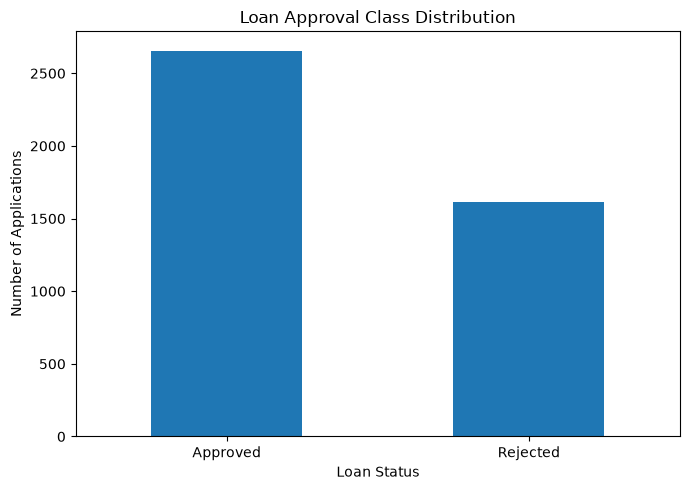

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

target_counts.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Loan Approval Class Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Number of Applications")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Categorical Feature Analysis

The categorical variables are evaluated using frequency tables and group-level approval rates. Since the target will later be encoded as one for approved and zero for rejected, the mean target value within each category represents the observed approval rate.

In [8]:
eda_df = clean_df.copy()
eda_df["loan_status_binary"] = (
    eda_df[target_column]
    .map({"Rejected": 0, "Approved": 1})
)

categorical_columns = (
    clean_df
    .select_dtypes(include=["object", "category"])
    .columns
    .drop(target_column)
    .tolist()
)

for column in categorical_columns:
    print(f"\nFrequency distribution for {column}:")
    display(
        clean_df[column]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(
            percentage=lambda table:
            table["count"] / len(clean_df) * 100
        )
    )

    print(f"Approval rate by {column}:")
    display(
        eda_df.groupby(column)["loan_status_binary"]
        .agg(application_count="size", approval_rate="mean")
        .assign(
            approval_rate=lambda table:
            table["approval_rate"] * 100
        )
        .sort_values("approval_rate", ascending=False)
    )


Frequency distribution for education:


,count,percentage
education,,
Graduate,2144,50.2225
Not Graduate,2125,49.7775


Approval rate by education:


,application_count,approval_rate
education,,
Graduate,2144,62.4534
Not Graduate,2125,61.9765



Frequency distribution for self_employed:


,count,percentage
self_employed,,
Yes,2150,50.3631
No,2119,49.6369


Approval rate by self_employed:


,application_count,approval_rate
self_employed,,
Yes,2150,62.2326
No,2119,62.1992


### Numerical Feature Comparison by Loan Status

Comparing feature averages between approved and rejected applications provides an initial indication of potentially informative variables. XGBoost can still identify nonlinear thresholds and feature interactions that are not visible from averages alone.

In [9]:
numerical_columns = (
    clean_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

numerical_status_comparison = (
    clean_df.groupby(target_column)[numerical_columns]
    .mean()
    .T
)

numerical_status_comparison["absolute_difference"] = (
    numerical_status_comparison["Approved"]
    - numerical_status_comparison["Rejected"]
).abs()

display(
    numerical_status_comparison.sort_values(
        "absolute_difference",
        ascending=False,
    )
)

loan_status,Approved,Rejected,absolute_difference
loan_amount,"15,247,251.5060","14,946,063.2362","301,188.2698"
luxury_assets_value,"15,016,603.9157","15,306,943.5834","290,339.6677"
residential_assets_value,"7,399,811.7470","7,592,498.4501","192,686.7031"
income_annum,"5,025,903.6145","5,113,825.1705","87,921.5560"
commercial_assets_value,"5,001,355.4217","4,926,720.3968","74,635.0249"
bank_asset_value,"4,959,525.6024","5,004,959.7024","45,434.1000"
cibil_score,703.4620,429.4681,273.9939
loan_term,10.3976,11.7285,1.3309
no_of_dependents,2.4748,2.5381,0.0634


### Correlation Analysis

The correlation matrix measures linear association among numerical features. Strong correlation does not necessarily require feature removal for tree-based models, but it can reveal redundant financial variables and provide useful context for later interpretation.

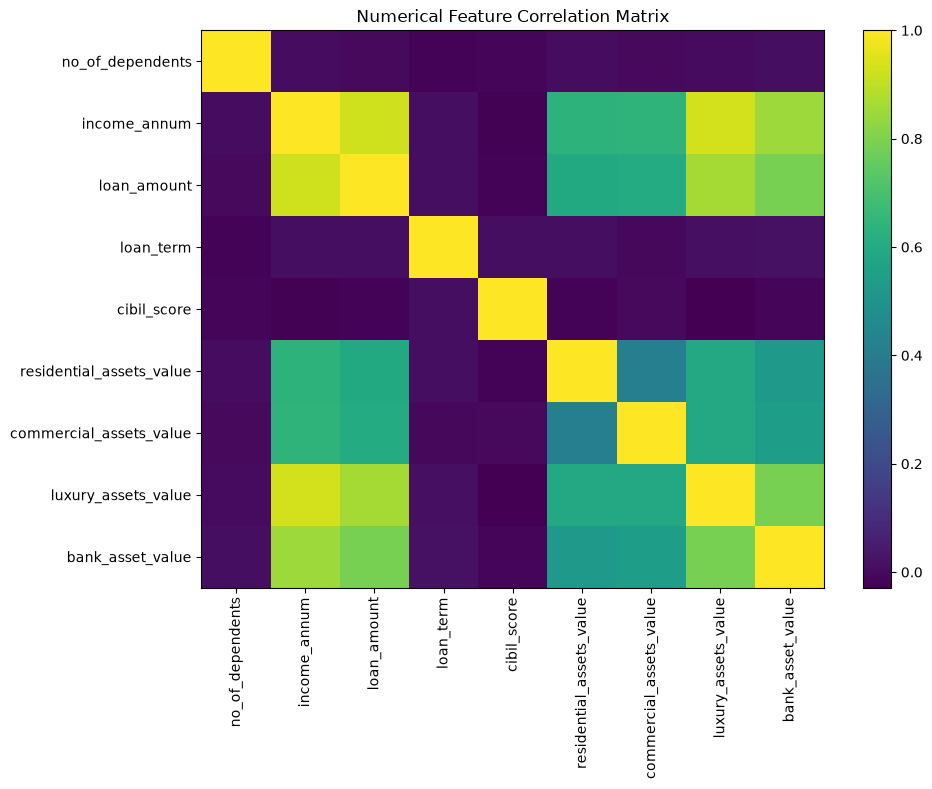

In [10]:
correlation_matrix = clean_df[numerical_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Numerical Feature Correlation Matrix")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

# Target Variable Selection

Before building the regression models, the target variable must be clearly defined.

The original dataset contains both numerical and categorical variables. Since this project focuses on regression, the target variable should be continuous rather than categorical.

The **Loan Amount** column is selected as the prediction target because it represents a continuous numerical value and is one of the most important variables in the loan approval process.

The remaining features will be used as predictors to estimate the requested loan amount.

In [11]:
# ======================================
# Features & Target
# ======================================

target = " loan_amount"

X = df.drop(columns=[target, " loan_status", "loan_id"])
y = df[target]

print(f"Target Variable : {target}")
print(f"Number of Features : {X.shape[1]}")

display(X.head())
display(y.head())

Target Variable :  loan_amount
Number of Features : 10


,no_of_dependents,education,self_employed,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,20,382,12400000,8200000,29400000,5000000


0    29900000
1    12200000
2    29700000
3    30700000
4    24200000
Name:  loan_amount, dtype: int64

___
# Train-Test Split

To evaluate the generalization capability of the regression models, the dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

The training data will be used to fit the models, while the testing data will remain unseen during training and will be used for final evaluation.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training Shape : {X_train.shape}")
print(f"Testing Shape  : {X_test.shape}")

Training Shape : (3415, 10)
Testing Shape  : (854, 10)


# Data Preprocessing

Machine learning algorithms require numerical inputs.

Therefore, categorical features are encoded using **One-Hot Encoding**, while numerical features are passed through without modification.

A preprocessing pipeline is created to ensure that the exact same transformations are applied during both training and prediction.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ===============================
# Features
# ===============================

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features")
display(categorical_features)

print("Numerical Features")
display(numerical_features)

# ===============================
# Linear Models Preprocessor
# ===============================

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

# ===============================
# Tree Models Preprocessor
# ===============================

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing Pipelines Created Successfully.")

Categorical Features


[' education', ' self_employed']

Numerical Features


[' no_of_dependents',
 ' income_annum',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value']

Preprocessing Pipelines Created Successfully.


# Linear Regression

Linear Regression is used as the baseline regression model.

It assumes a linear relationship between the independent variables and the target variable. Although financial data often contains non-linear relationships, Linear Regression provides an important benchmark against which more sophisticated machine learning models can be evaluated.

The model performance is assessed using the following evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

,Metric,Value
0,MAE,"2,626,034.5370"
1,MSE,"11,915,621,630,392.5371"
2,RMSE,"3,451,901.1617"
3,R² Score,0.8514


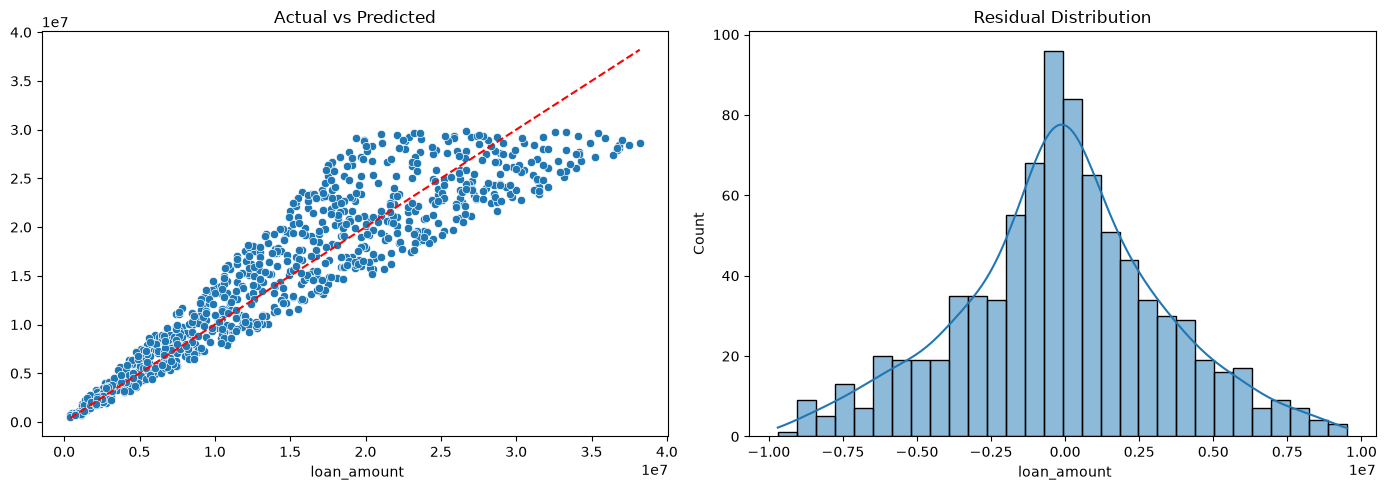

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

linear_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [linear_mae, linear_mse, linear_rmse, linear_r2]
})

display(linear_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=y_test,
    y=linear_pred,
    ax=axes[0]
)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test - linear_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Ridge Regression

Ridge Regression extends Linear Regression by introducing L2 regularization, which penalizes large coefficient values.

This regularization technique helps reduce overfitting, improves model generalization, and performs particularly well when numerical features exhibit multicollinearity.

The model uses the same preprocessing pipeline as Linear Regression, including feature scaling.

In [20]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha":[0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train,y_train)

best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test,ridge_pred)
ridge_mse = mean_squared_error(y_test,ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test,ridge_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[ridge_mae,ridge_mse,ridge_rmse,ridge_r2]
}))

print(ridge_grid.best_params_)

,Metric,Value
0,MAE,"2,625,400.5643"
1,MSE,"11,909,193,214,584.9551"
2,RMSE,"3,450,969.8948"
3,R² Score,0.8515


{'model__alpha': 1}


# Lasso Regression

Lasso Regression applies L1 regularization, which not only reduces overfitting but can also eliminate less important features by shrinking their coefficients to zero.

This makes Lasso useful for automatic feature selection while maintaining good predictive performance.

In [21]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor",linear_preprocessor),
    ("model",Lasso(max_iter=10000))
])

lasso_params = {
    "model__alpha":[0.0001,0.001,0.01,0.1,1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train,y_train)

best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test,lasso_pred)
lasso_mse = mean_squared_error(y_test,lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test,lasso_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[lasso_mae,lasso_mse,lasso_rmse,lasso_r2]
}))

print(lasso_grid.best_params_)

,Metric,Value
0,MAE,"2,626,033.9300"
1,MSE,"11,915,616,663,152.5059"
2,RMSE,"3,451,900.4422"
3,R² Score,0.8514


{'model__alpha': 1}


# ElasticNet Regression

ElasticNet combines both L1 and L2 regularization.

By balancing Ridge and Lasso penalties, ElasticNet often achieves better stability and predictive performance, especially when dealing with correlated features.

In [22]:
from sklearn.linear_model import ElasticNet

elastic_pipeline = Pipeline([
    ("preprocessor",linear_preprocessor),
    ("model",ElasticNet(max_iter=10000))
])

elastic_params = {
    "model__alpha":[0.001,0.01,0.1,1],
    "model__l1_ratio":[0.2,0.5,0.8]
}

elastic_grid = GridSearchCV(
    elastic_pipeline,
    elastic_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train,y_train)

best_elastic = elastic_grid.best_estimator_

elastic_pred = best_elastic.predict(X_test)

elastic_mae = mean_absolute_error(y_test,elastic_pred)
elastic_mse = mean_squared_error(y_test,elastic_pred)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test,elastic_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[elastic_mae,elastic_mse,elastic_rmse,elastic_r2]
}))

print(elastic_grid.best_params_)

,Metric,Value
0,MAE,"2,624,960.6224"
1,MSE,"11,904,767,760,627.4160"
2,RMSE,"3,450,328.6453"
3,R² Score,0.8515


{'model__alpha': 0.001, 'model__l1_ratio': 0.5}


# Decision Tree Regressor

Decision Tree Regressor is capable of capturing complex nonlinear relationships without assuming linearity.

To reduce overfitting and improve generalization, GridSearchCV is used to optimize the most important hyperparameters.

In [23]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ("preprocessor",tree_preprocessor),
    ("model",DecisionTreeRegressor(random_state=42))
])

tree_params={
    "model__max_depth":[5,10,15,None],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4]
}

tree_grid=GridSearchCV(
    tree_pipeline,
    tree_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

tree_grid.fit(X_train,y_train)

best_tree=tree_grid.best_estimator_

tree_pred=best_tree.predict(X_test)

tree_mae=mean_absolute_error(y_test,tree_pred)
tree_mse=mean_squared_error(y_test,tree_pred)
tree_rmse=np.sqrt(tree_mse)
tree_r2=r2_score(y_test,tree_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[tree_mae,tree_mse,tree_rmse,tree_r2]
}))

print(tree_grid.best_params_)

,Metric,Value
0,MAE,"2,622,257.8660"
1,MSE,"12,104,552,611,024.8281"
2,RMSE,"3,479,159.7565"
3,R² Score,0.8490


{'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


# Random Forest Regressor

Random Forest combines multiple decision trees using bootstrap aggregation (Bagging).

Compared with a single Decision Tree, Random Forest usually produces more stable predictions and better generalization performance.

,Metric,Value
0,MAE,"2,614,357.6849"
1,MSE,"11,775,463,158,987.9492"
2,RMSE,"3,431,539.4736"
3,R² Score,0.8531


Best Parameters
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}


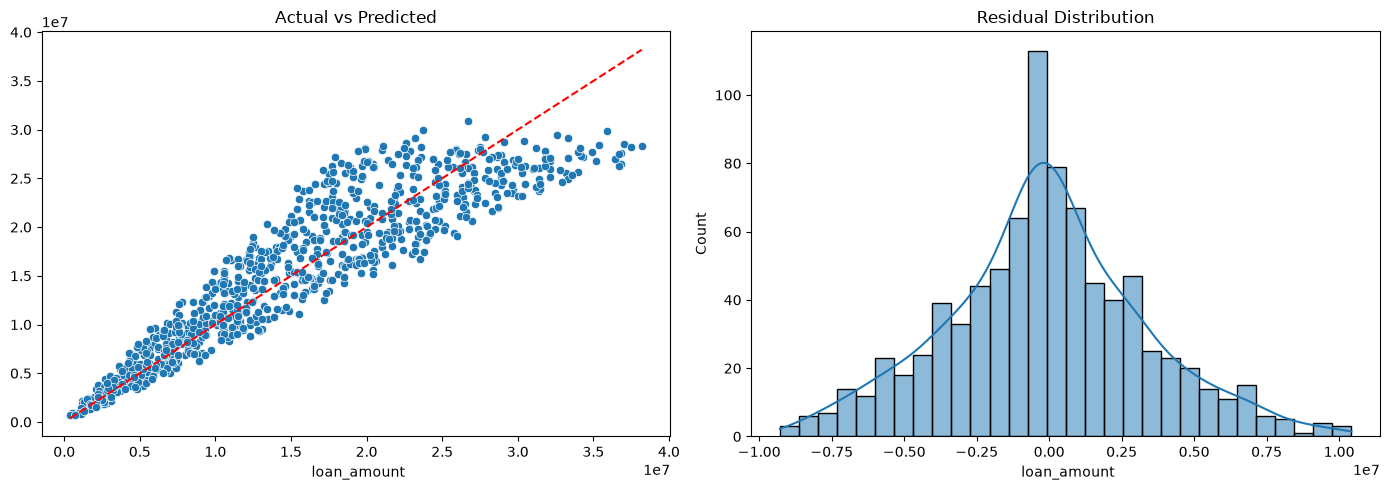

In [25]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

# ======================================================
# Random Forest Regressor
# ======================================================

rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[rf_mae,rf_mse,rf_rmse,rf_r2]
}))

print("Best Parameters")
print(rf_grid.best_params_)

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test-rf_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# XGBoost Regressor

XGBoost is an advanced gradient boosting algorithm that builds trees sequentially to minimize prediction errors.

It is one of the most powerful machine learning algorithms for structured tabular data and frequently achieves state-of-the-art regression performance.

,Metric,Value
0,MAE,"2,594,019.7500"
1,MSE,"11,606,246,293,504.0000"
2,RMSE,"3,406,794.1372"
3,R² Score,0.8553


Best Parameters
{'model__colsample_bytree': 1, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


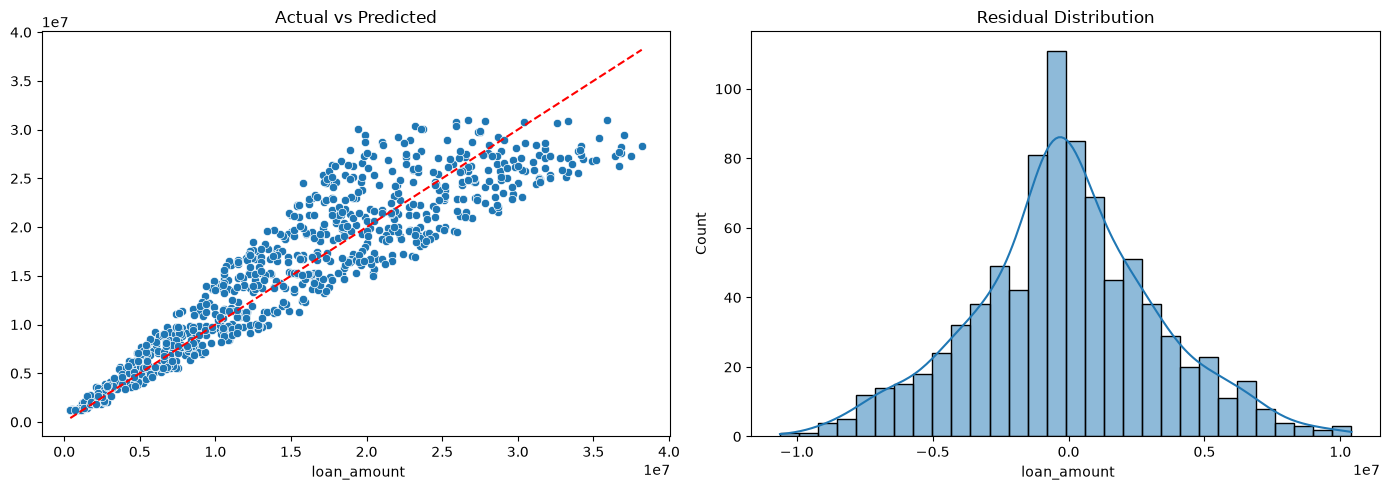

In [26]:
from xgboost import XGBRegressor

# ======================================================
# XGBoost Regressor
# ======================================================

xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators":[200,400],
    "model__learning_rate":[0.03,0.05,0.1],
    "model__max_depth":[3,5,7],
    "model__subsample":[0.8,1],
    "model__colsample_bytree":[0.8,1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train,y_train)

best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_mse = mean_squared_error(y_test,xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test,xgb_pred)

display(pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Value":[xgb_mae,xgb_mse,xgb_rmse,xgb_r2]
}))

print("Best Parameters")
print(xgb_grid.best_params_)

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(
    x=y_test,
    y=xgb_pred,
    ax=axes[0]
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

axes[0].set_title("Actual vs Predicted")

sns.histplot(
    y_test-xgb_pred,
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Model Comparison

All regression models are evaluated using the same testing dataset.

The comparison focuses on four standard regression metrics to determine which algorithm provides the most accurate predictions.

The best model is selected according to:

- Highest R² Score
- Lowest RMSE
- Lowest MAE

In [27]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        tree_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        tree_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R² Score":[
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        tree_r2,
        rf_r2,
        xgb_r2
    ]

}).sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,MAE,RMSE,R² Score
0,XGBoost,"2,594,019.7500","3,406,794.1372",0.8553
1,Random Forest,"2,614,357.6849","3,431,539.4736",0.8531
2,ElasticNet,"2,624,960.6224","3,450,328.6453",0.8515
3,Ridge Regression,"2,625,400.5643","3,450,969.8948",0.8515
4,Lasso Regression,"2,626,033.9300","3,451,900.4422",0.8514
5,Linear Regression,"2,626,034.5370","3,451,901.1617",0.8514
6,Decision Tree,"2,622,257.8660","3,479,159.7565",0.8490


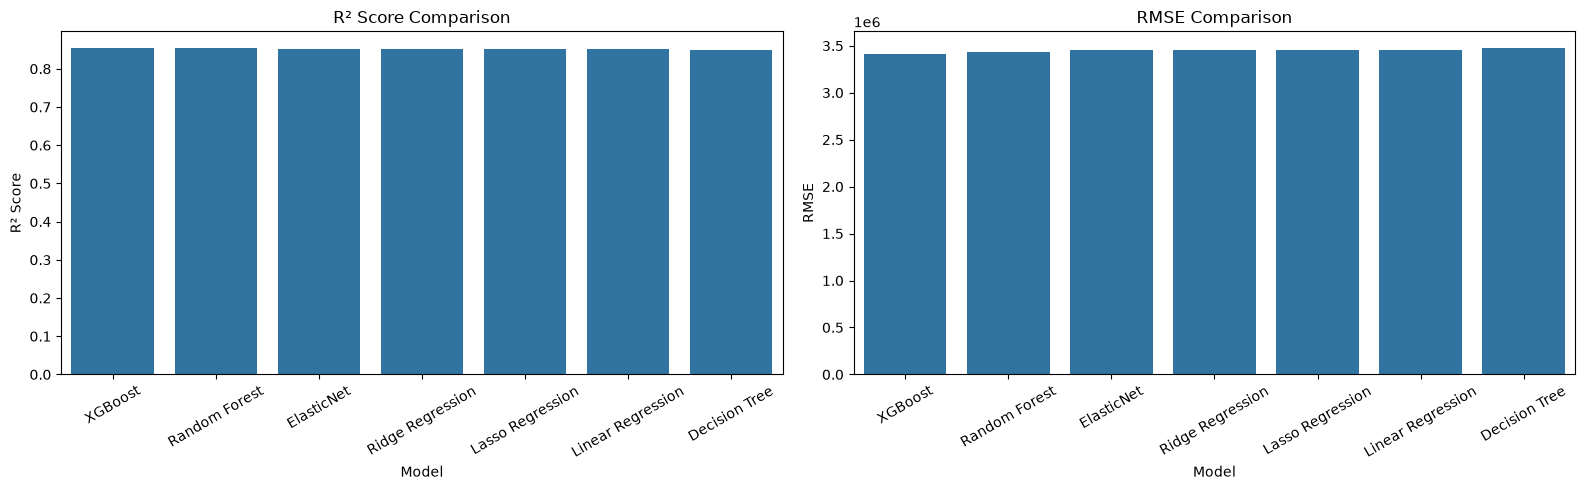

In [28]:
fig, axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score",
    ax=axes[0]
)

axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("R² Score Comparison")

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[1]
)

axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("RMSE Comparison")

plt.tight_layout()
plt.show()

In [29]:
best_model_name = comparison.iloc[0]["Model"]

models = {
    "Linear Regression": linear_pipeline,
    "Ridge Regression": best_ridge,
    "Lasso Regression": best_lasso,
    "ElasticNet": best_elastic,
    "Decision Tree": best_tree,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

best_model = models[best_model_name]

print("="*50)
print(f"Best Model : {best_model_name}")
print("="*50)

Best Model : XGBoost


# Feature Importance

Feature Importance provides insight into how much each feature contributes to the prediction process.

Since Linear Regression coefficients are not directly comparable to tree-based feature importance values, feature importance is extracted only when the selected best model is a tree-based algorithm.

Because the preprocessing pipeline applies One-Hot Encoding, the transformed feature names are retrieved directly from the preprocessing step to ensure correct interpretation.

,Feature,Importance
0,numerical__ income_annum,0.8529
1,numerical__ luxury_assets_value,0.0320
2,numerical__ bank_asset_value,0.0185
3,numerical__ residential_assets_value,0.0180
4,numerical__ commercial_assets_value,0.0157
5,numerical__ cibil_score,0.0153
6,numerical__ loan_term,0.0152
7,numerical__ no_of_dependents,0.0144
8,categorical__ education_ Graduate,0.0108
9,categorical__ self_employed_ No,0.0072


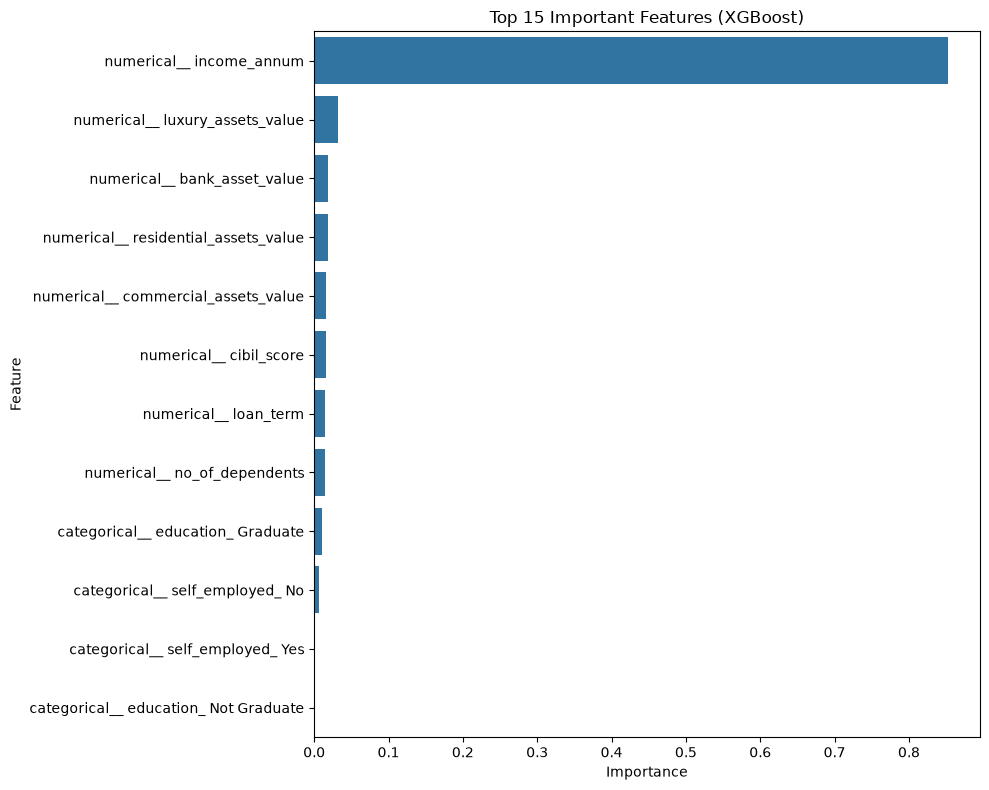

In [30]:
# =====================================================
# Feature Importance
# =====================================================

tree_models = ["Decision Tree", "Random Forest", "XGBoost"]

if best_model_name in tree_models:

    feature_names = best_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importance = best_model.named_steps[
        "model"
    ].feature_importances_

    feature_importance = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        })
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(feature_importance)

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Important Features ({best_model_name})")

    plt.tight_layout()

    plt.show()

else:

    print("Feature Importance is only available for tree-based models.")

# Save the Best Model

The best-performing regression model is saved using Joblib.

Saving the trained pipeline allows the complete preprocessing steps and trained model to be reused later without retraining.

The exported model will be loaded directly by the Streamlit application.

In [31]:
# =====================================================
# Save Model
# =====================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/best_loan_amount_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


# Prediction Function

A reusable prediction function is created to simplify future inference.

The function accepts the required customer information, converts it into the expected input format, and returns the predicted loan amount.

This function will be reused directly inside the Streamlit application.

In [ ]:

# =====================================================
# Final Prediction Function
# =====================================================

def predict_loan_amount(
    no_of_dependents,
    education,
    self_employed,
    income_annum,
    loan_term,
    cibil_score,
    residential_assets_value,
    commercial_assets_value,
    luxury_assets_value,
    bank_asset_value
):

    feature_columns = X.columns.tolist()
    feature_name_map = {col.strip(): col for col in feature_columns}

    sample = pd.DataFrame({
        "no_of_dependents": [no_of_dependents],
        "education": [education],
        "self_employed": [self_employed],
        "income_annum": [income_annum],
        "loan_term": [loan_term],
        "cibil_score": [cibil_score],
        "residential_assets_value": [residential_assets_value],
        "commercial_assets_value": [commercial_assets_value],
        "luxury_assets_value": [luxury_assets_value],
        "bank_asset_value": [bank_asset_value]
    })

    sample.columns = sample.columns.str.strip()
    sample = sample.rename(columns=feature_name_map)
    sample = sample.reindex(columns=feature_columns)

    prediction = best_model.predict(sample)[0]
    return round(prediction, 2)

example = predict_loan_amount(
    no_of_dependents=2,
    education=" Graduate",
    self_employed=" No",
    income_annum=6500000,
    loan_term=12,
    cibil_score=780,
    residential_assets_value=7000000,
    commercial_assets_value=2500000,
    luxury_assets_value=9000000,
    bank_asset_value=3000000
)

print(f"Predicted Loan Amount: {example}")

Predicted Loan Amount: 18755150.0
Predicted Loan Amount: 18755150.0


# Project Conclusion

In this project, multiple regression algorithms were developed and evaluated to predict the loan amount based on applicant information and financial assets.

The following models were implemented:

- Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Each model was trained using an appropriate preprocessing pipeline and evaluated using MAE, RMSE, and R² Score.

After comparing all models, the best-performing algorithm was selected automatically based on its predictive performance.

Finally, the trained model was exported and wrapped inside a reusable prediction function, making it ready for deployment in a Streamlit web application.